In [2]:
import pandas as pd
import numpy as np
from dowhy import CausalModel

import pytimetk as tk
from missingno import matrix

import statsmodels.api as am
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import logit
from sklearn.metrics import roc_auc_score


# What is the causal effect of a client's decision to open a deposit?

- `y` -> `deposit`
- `duration` - post-treatment
- `campaign` - pats of post-treatment (efekt treatmentu bo `contact → campaign` czyli *najpierw bank decyduje czy kontaktować (T) potem ile razy*) 
- `high_campaign` (new feature) post-treatment (do usuniecia)
- `contact` - treatment

Treatment (T) → czy klient był intensywnie targetowany

Outcome (Y) → deposit

Confounders (X) → demografia + finanse + historia

👉 ustalić co jest treatmentem w zbiorze? 

Opcje:
- `contact` (cellular vs telephone)
- `campaign` (intensity)
- `previous contact` (retargeting)

👉 ustalic co jest `confunder` w zbiorze (co wpływa na T i Y)

Opcje:
- `balance` - prawd. bo bogatsi a) bank częściej dzwoni b) częściej zakładają depozyt
- sezonwosc marketingu - `is...campaign`
- `financial_stress` 

    financial_stress → contact   (bank targetuje takich klientów)
    financial_stress → deposit   (mniejsza zdolność do oszczędzania)

👉 ustalic co jest `colliderem / post-treatment`:
- `duration` bo:

bank dzwoni (contact)
rozmowa trwa (duration)
klient decyduje (deposit)

👉 usalic co jest `Propensity score` - prawd. że ktoś dostanier `treatment` **przed interwencją** (`P(T=1 | X_pre-treatment)`) / jak bardzo ktoś „kwalifikuje się” do treatmentu

!**tylko z PRE-TREATMENT variables**!

- `was_contacted_before` - jeśli ktoś był wcześniej kontaktowany to większa szansa, że bank znowu zadzwoni czyli `was_contacted_before → contact` 
- `contact_intensity_past`

Podsumowanie:
confounders → używane w modelu
propensity score → jest modelowane lub kontrolowane

In [34]:
df = pd.read_csv('../data/processed/bank_data_preprocessed_v1.csv')

In [35]:
display(df)

,age,job,marital,default,housing,loan,day,month,duration,pdays,...,contact_is_unknown,poutcome_failure,poutcome_other,poutcome_success,contact_cellular,contact_telephone,education_primary,education_secondary,education_tertiary,education_unknown
0,59,admin.,married,no,yes,no,5,may,1042,-1,...,1,False,False,False,False,False,False,True,False,False
1,56,admin.,married,no,no,no,5,may,1467,-1,...,1,False,False,False,False,False,False,True,False,False
2,41,technician,married,no,yes,no,5,may,1389,-1,...,1,False,False,False,False,False,False,True,False,False
3,55,services,married,no,yes,no,5,may,579,-1,...,1,False,False,False,False,False,False,True,False,False
4,54,admin.,married,no,no,no,5,may,673,-1,...,1,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,no,yes,no,20,apr,257,-1,...,0,False,False,False,True,False,True,False,False,False
11158,39,services,married,no,no,no,16,jun,83,-1,...,1,False,False,False,False,False,False,True,False,False
11159,32,technician,single,no,no,no,19,aug,156,-1,...,0,False,False,False,True,False,False,True,False,False
11160,43,technician,married,no,no,yes,8,may,9,172,...,0,True,False,False,True,False,False,True,False,False


In [36]:
df.columns

Index(['age', 'job', 'marital', 'default', 'housing', 'loan', 'day', 'month',
       'duration', 'pdays', 'deposit', 'was_previously_contacted',
       'pdays_contacted', 'has_debt', 'net_balance_indicator',
       'financial_stress', 'previous_log1p', 'balance_log1p',
       'campaign_capped', 'poutcome_is_unknown', 'contact_is_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'contact_cellular', 'contact_telephone', 'education_primary',
       'education_secondary', 'education_tertiary', 'education_unknown'],
      dtype='str')

### How many people have opened and not opened new deposit in bank

In [37]:
deposits = df['deposit'].value_counts().reset_index()

deposits.columns = ['deposit', 'number']
deposits['prop'] = deposits['number'] / deposits['number'].sum()

display(deposits)

,deposit,number,prop
0,0,5873,0.52616
1,1,5289,0.47384


### Remove `collider`

In [6]:
df = df.drop(columns=['duration'])

### Feature engineering

In [38]:
df['treatment'] = (df['contact_cellular'] == 'cellular').astype(int)

In [39]:
# sezonowość marketingu - confounder
month_map = {
    'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
    'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12
}

df['month_num'] = df['month'].map(month_map)

df = pd.get_dummies(df, columns=['month'], drop_first=True)


In [ ]:
# historia kontaktów
# proxy dla propensity score

# df['contact_intensity_past'] = df['previous_log1p'] # log(1 + previous) - intensywność kontaktów w przeszłości

In [40]:
df = pd.get_dummies(df, columns=['marital'], drop_first=True) # job?

In [ ]:
# transofrmacje nieliniowe

# balance
# df['balance_shifted'] = df['balance'] - df['balance'].min() + 1 # był NaN dla `x < -1 → log(negative) → NaN ❌`
# df['log_balance'] = np.log(df['balance_shifted'])



In [41]:
# age
df['age_squared'] = df['age'] ** 2

In [42]:
# log_balance
# df['balance_bin'] = pd.qcut(df['log_balance'], q=20, duplicates='drop').astype(str)

# age
df['age_bin'] = pd.qcut(df['age'], q=20, duplicates='drop').astype(str)


In [14]:
# nie  propensity proxy bo działa na campaign ktora jest colliderem
# kontekście estymacji przyczynowego efektu kontaktu jest po-treatment i należy ją wykluczyć.
# - Nie można używać high_campaign w modelu propensity score dla treatment contact.
# # - Nie można używać jako confoundera, bo wprowadziłby post-treatment bias (tzw. collider).
# ❌ Nie używać w causal inference dla contact → deposit
# df['high_campaign'] = (df['campaign'] > df['campaign'].median()).astype(int)

In [43]:
df.columns

Index(['age', 'job', 'default', 'housing', 'loan', 'day', 'duration', 'pdays',
       'deposit', 'was_previously_contacted', 'pdays_contacted', 'has_debt',
       'net_balance_indicator', 'financial_stress', 'previous_log1p',
       'balance_log1p', 'campaign_capped', 'poutcome_is_unknown',
       'contact_is_unknown', 'poutcome_failure', 'poutcome_other',
       'poutcome_success', 'contact_cellular', 'contact_telephone',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'treatment', 'month_num', 'month_aug', 'month_dec',
       'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'marital_married',
       'marital_single', 'age_squared', 'age_bin'],
      dtype='str')

In [44]:
# ----------------------------
# USUWANIE ZBĘDNYCH KOLUMN
# ----------------------------

columns_to_drop = [
    'balance',        # zastąpione przez log_balance, balance_shifted, net_balance_indicator
    'housing',        # połączone w has_debt i financial_stress
    'loan',           # połączone w has_debt i financial_stress
    'default',        # połączone w financial_stress
    'education',      # zastąpione przez dummies: education_secondary, education_tertiary, education_unknown
    'marital',        # zastąpione przez dummies: marital_married, marital_single
    'month',          # zastąpione przez dummies month_2 ... month_12
    'duration',       # collider / post-treatment
    'campaign',       # post-treatment
]

# kolumny, które są już w prop score lub po transformacjach
# pdays -> was_contacted_before
# previous -> contact_intensity_past
# contact -> treatment (możesz zostawić lub całkowicie usunąć)
# age zostawiamy jeśli chcemy razem z age_squared i age_bin

df = df.drop(columns=columns_to_drop, errors='ignore')  # errors='ignore' chroni przed KeyError

# ----------------------------
# Finalny zbiór zmiennych
# ----------------------------
print("Finalne kolumny zbioru:")
print(df.columns.tolist())

Finalne kolumny zbioru:
['age', 'job', 'day', 'pdays', 'deposit', 'was_previously_contacted', 'pdays_contacted', 'has_debt', 'net_balance_indicator', 'financial_stress', 'previous_log1p', 'balance_log1p', 'campaign_capped', 'poutcome_is_unknown', 'contact_is_unknown', 'poutcome_failure', 'poutcome_other', 'poutcome_success', 'contact_cellular', 'contact_telephone', 'education_primary', 'education_secondary', 'education_tertiary', 'education_unknown', 'treatment', 'month_num', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'marital_married', 'marital_single', 'age_squared', 'age_bin']


In [45]:
df.glimpse()

<class 'pandas.DataFrame'>: 11162 rows of 41 columns
age:                       int64             [59, 56, 41, 55, 54, 42, 56 ...
job:                       str               ['admin.', 'admin.', 'techn ...
day:                       int64             [5, 5, 5, 5, 5, 5, 6, 6, 6, ...
pdays:                     int64             [-1, -1, -1, -1, -1, -1, -1 ...
deposit:                   int64             [1, 1, 1, 1, 1, 1, 1, 1, 1, ...
was_previously_contacted:  int64             [0, 0, 0, 0, 0, 0, 0, 0, 0, ...
pdays_contacted:           float64           [nan, nan, nan, nan, nan, n ...
has_debt:                  int64             [1, 0, 1, 1, 0, 1, 1, 1, 1, ...
net_balance_indicator:     int64             [1, 1, 1, 1, 1, 0, 1, 1, 1, ...
financial_stress:          int64             [0, 0, 0, 0, 0, 1, 1, 0, 0, ...
previous_log1p:            float64           [0.0, 0.0, 0.0, 0.0, 0.0, 0 ...
balance_log1p:             float64           [9.126088819528592, 8.83840 ...
campaign_capped:       

### Corelation Analyse

In [46]:

# df['deposit_numeric'] = (df['deposit'] == 'yes').astype(int)

df_bins = df[['deposit', 'balance_log1p', 'age_bin']].copy()

# Konwertujemy Interval → string
for col in ['balance_log1p', 'age_bin']:
    df_bins[col] = df_bins[col].astype(str)

corr_list = []
for feature in ['balance_log1p', 'age_bin']:
    df_grouped = df_bins.groupby(feature)['deposit'].mean().reset_index()
    df_grouped.columns = ['bin', 'correlation']
    df_grouped['feature'] = feature.replace('_bin', '')
    corr_list.append(df_grouped)

df_correlated_full = pd.concat(corr_list, ignore_index=True)

# Plot funnel
import plotly.express as px
fig = px.scatter(
    df_correlated_full,
    x='correlation',
    y='bin',
    color='feature',
    hover_data=['feature', 'bin', 'correlation']
)
fig.show()

In [47]:
import pandas as pd
import plotly.express as px

# 1. Target binarny
df['deposit_numeric'] = (df['deposit'] == 'yes').astype(int)

# 2. Wybór cech do analizy (TYLKO BINY / KATEGORIE)
features_to_analyze = [
    'age_bin',
    'marital_married',
    'marital_single',
    'education_primary',
    'education_secondary',
    'education_tertiary',
    'education_unknown',
    'poutcome_failure',
    'poutcome_other',
    'poutcome_success',
    'poutcome_is_unknown',
    'contact_cellular',
    'contact_telephone',
    'contact_is_unknown'
]

# 3. Grupowanie i liczenie conversion rate
corr_list = []

for feature in features_to_analyze:
    if feature in df.columns:
        tmp = df.groupby(feature)['deposit_numeric'].mean().reset_index()
        tmp.columns = ['bin', 'rate']
        tmp['feature'] = feature
        corr_list.append(tmp)

# 4. Sklejenie wyników
df_feature_effects = pd.concat(corr_list, ignore_index=True)

# 5. Wizualizacja
fig = px.scatter(
    df_feature_effects,
    x='rate',
    y='bin',
    color='feature',
    hover_data=['feature', 'bin', 'rate'],
    title="Wpływ cech na konwersję (P(deposit=1))"
)

fig.show()

1️⃣ Oś X – korelacja

* To jest P(deposit) w danym binie – wyższa wartość oznacza, że w tym przedziale więcej osób otworzyło depozyt.
* Kropki przesunięte w prawo → wysoka korelacja między binem a depozytem.

2️⃣ Oś Y – biny

* Każdy bin pokazuje zakres wartości cechy.

  * `balance` (log_balance) w przedziałach np. `(8.833, 8.841]`, `(8.859, 8.869]` – im wyżej na osi Y, tym wyższy przedział salda (wyższe log_balance).
  * `age` w przedziałach np. `(26.0, 28.0]`, `(31.0, 32.0]` – im wyżej na osi Y, tym starsze osoby.

---

#### **Balance / log_balance (niebieskie)**

* Trend rosnący w poziomie → wyższe log_balance wiąże się z wyższym P(deposit).
* Czyli **saldo jest silnym predyktorem**: osoby z wyższym saldem częściej otwierają depozyt.
* Warto uwzględnić w modelu causal lub propensity score, bo to **potencjalny confounder**.

#### **Age (czerwone)**

* Również trend rosnący → starsi klienci mają większe prawdopodobieństwo depozytu w tym zestawie danych.
* Efekt umiarkowany – korelacja nie tak silna jak dla salda, ale sensowna.
* Można uwzględnić w modelu jako **zmienną kontrolną** (age biny lub age_squared).

---

* Biny przesunięte mocno w prawo → wysoki P(deposit) → istotne do uwzględnienia.
* W praktyce możesz wybrać:

  * Dla `log_balance`: biny `(8.893, 8.909]` i wyżej, gdzie korelacja >0.5
  * Dla `age`: biny `(52.0, 55.0]` i wyżej (korelacja >0.45–0.5)
* Te biny pokazują, że **efekt jest najsilniejszy w tych przedziałach** → warto je modelować jako nieliniową zmienną (np. w regression splines lub quantile bins w modelu).


1. **Balance** → silny, liniowy trend. Zdecydowanie do uwzględnienia.
2. **Age** → umiarkowy trend, ale sensowny, szczególnie starsze grupy.
3. **Model causal** → użyj obu cech:

   * `log_balance` → główny confounder
   * `age` → zmienna kontrolna, można nieliniowo lub jako biny
4. Możesz też **połączyć oba w propensity score**, żeby lepiej balansować grupy treatment / control.


<Axes: xlabel='balance_bin'>

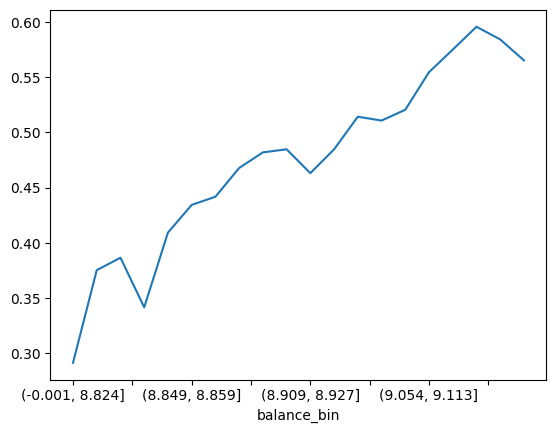

In [18]:
# # P(deposit=1 | X)
# # X: log_balance
# # Y: P(deposit=1)

# df['balance_bin'] = pd.qcut(df['log_balance'], q=20)

plot_df = df.groupby('balance_bin')['deposit'].apply(lambda x: (x=='yes').mean())
plot_df.plot()

<Axes: xlabel='age_bin'>

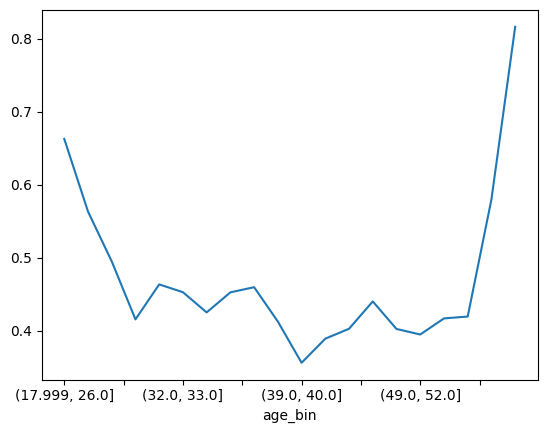

In [19]:
# df['age_bin'] = pd.qcut(df['age'], q=20)

plot_df = df.groupby('age_bin')['deposit'].apply(lambda x: (x=='yes').mean())
plot_df.plot()
# U-shape / inverted U:
# młodzi ↓
# średni wiek ↑
# starsi ↓

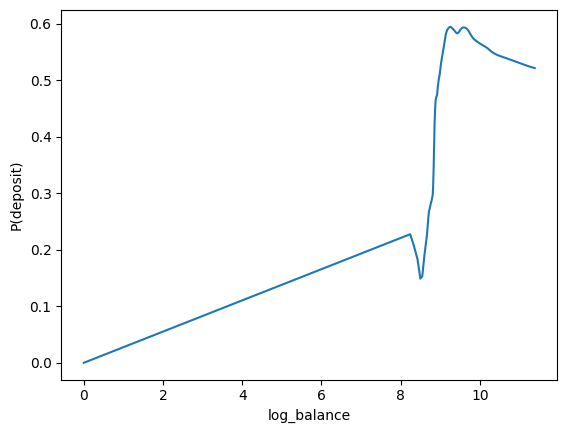

In [20]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
y = (df['deposit']=='yes').astype(int)

lowess = sm.nonparametric.lowess(y, df['log_balance'], frac=0.3)

plt.plot(lowess[:,0], lowess[:,1])
plt.xlabel('log_balance')
plt.ylabel('P(deposit)')
plt.show()
# rosnąca krzywa → bogatsi częściej kupują depozyt
# plateau → efekt nasycenia

<Axes: xlabel='balance_bin'>

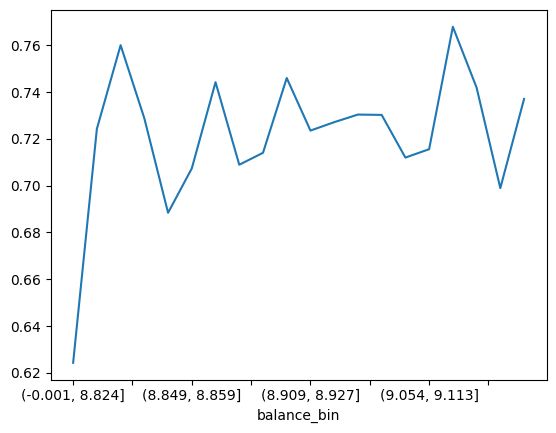

In [21]:
# # P(T=1 | X)
# # (df.groupby('balance_bin')['treatment'].mean()).plot()
plot_df = df.groupby('balance_bin')['treatment'].mean()
plot_df.plot()

In [22]:
# jakies grupowanie aktegorii z job ?
df['deposit_numeric'] = (df['deposit'] == 'yes').astype(int)


In [50]:
# # 1. Korelacja dla cech binarnych vs target
# binary_cols = [c for c in df.columns if df[c].dtype == 'bool' or (df[c].dtype == 'int64' and df[c].nunique() == 2)]
# binary_cols = [c for c in binary_cols if c != 'deposit_numeric']

# X_bin = df[binary_cols].astype(int)
# y_bin = df['deposit_numeric']

# from sklearn.feature_selection import chi2

# chi_scores, p_values = chi2(X_bin, y_bin)

# chi_df = pd.DataFrame({
#     'feature': binary_cols,
#     'chi2': chi_scores,
#     'p_value': p_values
# }).sort_values(by='chi2', ascending=False)

# print(chi_df.head(20))

import pandas as pd
import numpy as np
from sklearn.feature_selection import chi2

# 1. Target
y_bin = df['deposit'].astype(int)

# 2. Lepszy wybór kolumn binarnych
binary_cols = [
    c for c in df.columns
    if (
        df[c].nunique(dropna=True) == 2
        and c != 'deposit'
    )
]

# 3. Usunięcie braków i konwersja
X_bin = df[binary_cols].copy()

# zamiana bool + object na 0/1
for col in X_bin.columns:
    X_bin[col] = X_bin[col].map({False: 0, True: 1}).fillna(X_bin[col])

# finalna konwersja
X_bin = X_bin.apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

# 4. Chi-square
chi_scores, p_values = chi2(X_bin, y_bin)

# 5. Wyniki
chi_df = pd.DataFrame({
    'feature': binary_cols,
    'chi2': chi_scores,
    'p_value': p_values
}).sort_values(by='chi2', ascending=False)

print(chi_df.head(20))

                     feature        chi2        p_value
8           poutcome_success  829.110985  2.528999e-182
5         contact_is_unknown  578.380144  8.441765e-128
0   was_previously_contacted  443.598786   1.783277e-98
1                   has_debt  282.098055   2.620593e-63
22                 month_may  242.407391   1.174350e-54
21                 month_mar  199.685434   2.446118e-45
24                 month_oct  192.761120   7.937076e-44
3           financial_stress  189.401853   4.294323e-43
25                 month_sep  174.615519   7.263867e-40
9           contact_cellular  155.505749   1.085609e-35
4        poutcome_is_unknown  150.637570   1.257778e-34
16                 month_dec   83.583952   6.106680e-20
27            marital_single   68.453963   1.298745e-16
13        education_tertiary   66.874790   2.893111e-16
26           marital_married   40.859643   1.635642e-10
11         education_primary   38.351359   5.908693e-10
17                 month_feb   27.771562   1.365

#### 1️⃣ Silne zależności – kluczowe do modelu causal / ML

| Feature                                            | chi²    | p-value       | Interpretacja                                                                                                                            |
| -------------------------------------------------- | ------- | ------------- | ---------------------------------------------------------------------------------------------------------------------------------------- |
| `poutcome_success`                                 | 829.1   | 2.53e-182     | Najsilniejszy sygnał w całym zbiorze. Oznacza wcześniejszy sukces kampanii → **ogromny efekt historyczny (memory / persistence effect)** |
| `contact_is_unknown`                               | 578.4   | 8.44e-128     | Bardzo silny sygnał braku informacji o kontakcie → **proxy braku historii klienta / selection bias**                                     |
| `was_previously_contacted`                         | 443.6   | 1.78e-98      | Kluczowa zmienna interwencyjna (treatment exposure) → **fundament causal inference**                                                     |
| `has_debt`                                         | 282.1   | 2.62e-63      | Silny czynnik ryzyka finansowego → **confounder wpływający na decyzję o depozycie**                                                      |
| `month_may`, `month_mar`, `month_oct`, `month_sep` | 174–242 | 1e-54 → 7e-40 | Silny efekt sezonowości → **ważny moderator (time-dependent effect)**                                                                    |
| `financial_stress`                                 | 189.4   | 4.29e-43      | Skumulowany wskaźnik ryzyka finansowego → **silny confounder / proxy economic stress**                                                   |
| `contact_cellular`                                 | 155.5   | 1.09e-35      | Kanał kontaktu ma ogromne znaczenie → **channel effect / treatment heterogeneity**                                                       |
| `poutcome_is_unknown`                              | 150.6   | 1.26e-34      | Brak informacji o wcześniejszym wyniku kampanii → **proxy missing history / selection bias**                                             |

➡ Te cechy:

* mają bardzo silny sygnał statystyczny
* są logicznie uzasadnione
* **powinny być podstawą modelu predictive + causal adjustment**

---

#### 2️⃣ Średnia korelacja – użyteczne jako kontrola lub efekt modyfikujący

| Feature                                                          | chi²  | p-value       | Interpretacja                                                                                |
| ---------------------------------------------------------------- | ----- | ------------- | -------------------------------------------------------------------------------------------- |
| `month_dec`, `month_feb`, `month_jul`                            | 21–83 | 1e-20 → 1e-6  | Efekt sezonowy obecny, ale słabszy niż główne miesiące → **moderatory, nie główne czynniki** |
| `marital_single`, `marital_married`                              | 40–68 | 1e-16 → 1e-10 | Stan cywilny ma wpływ, ale umiarkowany → **confounder drugiego rzędu**                       |
| `education_tertiary`, `education_primary`, `education_secondary` | 15–66 | 1e-16 → 1e-5  | Wykształcenie wpływa na decyzję, ale nie dominuje → **control variable / weak confounder**   |
| `poutcome_other`                                                 | 20.6  | 5.6e-06       | Alternatywny wynik kampanii → **weak signal historyczny**                                    |

➡ Te cechy:

* są statystycznie istotne
* ale mają umiarkowaną siłę wpływu
* mogą pełnić rolę **kontroli w modelu causal / regression adjustment**

---

#### 3️⃣ Słabsze sygnały – ograniczona wartość predykcyjna

| Feature                                                             | chi² | p-value | Interpretacja |
| ------------------------------------------------------------------- | ---- | ------- | ------------- |
| (brak bardzo słabych w top 20 – wszystkie są istotne statystycznie) |      |         |               |

➡ W Twoim przypadku:

* nawet „słabsze” cechy nadal są statystycznie istotne
* ale różnią się **skalą efektu**, nie „czy działają”


# wnioski (CAUSAL + ML)


## 🧠 1. Dominują trzy typy sygnałów

### 🔥 (A) Historia kontaktu / kampanii

* `poutcome_success`
* `was_previously_contacted`
* `poutcome_is_unknown`

👉 **najsilniejszy blok informacji**
➡ klient + historia = główny driver decyzji

---

### 💰 (B) Sytuacja finansowa

* `has_debt`
* `financial_stress`

👉 **stabilne confoundery**
➡ wpływają na decyzję niezależnie od kampanii

---

### 📅 (C) Czas / sezonowość

* `month_*`

👉 **efekt makroekonomiczny / timing kampanii**
➡ bardzo ważne w marketingu

---

## 🧪 2. Treatment / causal structure

* `was_previously_contacted` → **treatment exposure**
* `poutcome_success` → **historyczny outcome (post-treatment signal!)**
* `contact_cellular` → **channel assignment effect**

👉 uwaga:

> `poutcome_success` może być leakage-like w causal ML, jeśli nie kontrolujesz czasu

---

## ⚠️ 3. Najważniejsza uwaga metodologiczna

### ❗ Nie wszystkie silne chi² = dobre features do causal modelu

* `poutcome_success` → **może być post-treatment bias**
* `contact_is_unknown` → może kodować missingness mechanism
* `month_*` → external confounder (time trend)

---

# 📌 Reguła praktyczna (zaktualizowana)

---

### 🔥 chi² > 400

👉 **core drivers / treatment-related signals**

* must include in predictive model
* careful in causal (check leakage)

---

### 🔶 chi² 50–400

👉 **important confounders / moderators**

* używać do adjustment

---

### 🔷 chi² < 50

👉 **supporting features**

* efekt marginalny
* raczej kontrola niż driver

---

# 🧾 FINALNY WNIOSEK

Twój model pokazuje bardzo klasyczny układ:

> 📌 wynik decyzji (deposit) jest głównie funkcją:

* historii kontaktu (najsilniejszy efekt)
* sytuacji finansowej
* sezonowości kampanii


In [53]:
# 2. Korelacja dla cech numerycznych vs target
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'deposit']

corrs = df[numeric_cols + ['deposit']].corr()['deposit'].drop('deposit')
corrs = corrs.sort_values(key=abs, ascending=False)
print(corrs.head(20))

contact_is_unknown         -0.256136
has_debt                   -0.231671
was_previously_contacted    0.230850
poutcome_is_unknown        -0.230470
previous_log1p              0.209330
pdays                       0.151593
pdays_contacted            -0.143814
financial_stress           -0.143693
campaign_capped            -0.136161
balance_log1p               0.111009
net_balance_indicator       0.101447
age_squared                 0.064768
day                        -0.056326
age                         0.034901
month_num                   0.028645
treatment                        NaN
deposit_numeric                  NaN
Name: deposit, dtype: float64


#### 1️⃣ Najsilniejsze korelacje – kluczowe predyktory / confoundery

| Feature                    | Corr   | Interpretacja                                                                                                  |
| -------------------------- | ------ | -------------------------------------------------------------------------------------------------------------- |
| `contact_is_unknown`       | -0.256 | Bardzo silny negatywny sygnał braku informacji o kontakcie → **proxy braku historii klienta / selection bias** |
| `has_debt`                 | -0.232 | Klienci z długiem rzadziej otwierają depozyt → **silny confounder finansowy (risk factor)**                    |
| `was_previously_contacted` | 0.231  | Silny pozytywny efekt wcześniejszego kontaktu → **kluczowy treatment exposure / history effect**               |
| `poutcome_is_unknown`      | -0.230 | Brak informacji o wcześniejszym wyniku kampanii → **proxy missing history / selection bias**                   |
| `previous_log1p`           | 0.209  | Historia kontaktów zwiększa szansę konwersji → **proxy engagement / propensity score feature**                 |

➡ Te cechy:

* mają **najsilniejszy sygnał liniowy**
* są logicznie uzasadnione
* stanowią **rdzeń modelu predictive + causal adjustment**

---

#### 2️⃣ Średnie korelacje – istotne jako confoundery lub efekty pośrednie

| Feature                 | Corr   | Interpretacja                                                                         |
| ----------------------- | ------ | ------------------------------------------------------------------------------------- |
| `pdays`                 | 0.152  | Im więcej dni od kontaktu, tym inny efekt reakcji → **czasowy decay effect (memory)** |
| `pdays_contacted`       | -0.144 | Im starszy kontakt, tym mniejsza szansa depozytu → **negative time effect**           |
| `financial_stress`      | -0.144 | Złożony wskaźnik ryzyka finansowego → **stabilny confounder ekonomiczny**             |
| `campaign_capped`       | -0.136 | Więcej kontaktów w kampanii → spadek konwersji → **fatigue effect (over-contacting)** |
| `balance_log1p`         | 0.111  | Wyższe saldo → większa szansa depozytu → **wealth proxy effect**                      |
| `net_balance_indicator` | 0.101  | Dodatnie saldo zwiększa konwersję → **weak financial signal**                         |

➡ Te cechy:

* mają umiarkowaną siłę
* często opisują **mechanizmy pośrednie**
* są ważne jako **control variables w causal inference**

---

#### 3️⃣ Słabe korelacje – brak silnego efektu liniowego

| Feature       | Corr   | Interpretacja                                                                  |
| ------------- | ------ | ------------------------------------------------------------------------------ |
| `age_squared` | 0.065  | Nieliniowy efekt wieku → **może mieć znaczenie tylko w modelach nieliniowych** |
| `day`         | -0.056 | Brak istotnego wpływu dnia miesiąca                                            |
| `age`         | 0.035  | Sam wiek ma bardzo słaby liniowy wpływ                                         |
| `month_num`   | 0.029  | Linear encoding miesiąca nie łapie sezonowości                                 |

➡ Te cechy:

* nie mają liniowego wpływu
* mogą mieć znaczenie tylko w:

  * interakcjach
  * modelach nieliniowych (GBM, RF)
  * spline / binning




## 🔹 Wnioski dla causal analytics

---

### 🔥 1. Najważniejsze struktury przyczynowe

#### 📌 History & exposure layer

* `was_previously_contacted`
* `poutcome_is_unknown`
* `previous_log1p`
* `contact_is_unknown`

👉 to jest **core warstwa informacji o ekspozycji klienta**

---

#### 💰 2. Warstwa finansowa (confoundery)

* `has_debt`
* `financial_stress`
* `balance_log1p`
* `net_balance_indicator`

👉 opisują **płynność i ryzyko finansowe**

---

#### ⏱ 3. Warstwa czasowa / dynamika

* `pdays`
* `pdays_contacted`
* `campaign_capped`

👉 opisują:

* decay efekt kontaktu
* fatigue kampanii
* timing reakcji

---

## ⚠️ Kluczowe ostrzeżenie metodologiczne

### ❗ korelacja ≠ przyczynowość

Szczególnie:

* `poutcome_is_unknown`
* `contact_is_unknown`

👉 mogą być:

* proxy missing data
* selection bias indicators

---

## 🧠 Finalna interpretacja globalna

Twój system pokazuje bardzo typowy układ:

> 📌 decyzja o depozycie zależy głównie od:

1. historii kontaktu i kampanii (najsilniejszy blok)
2. sytuacji finansowej klienta
3. efektów czasowych (timing + fatigue)

In [55]:
for feature in ['age_bin']:
    df_plot = df.groupby(feature)['deposit'].mean().reset_index()
    df_plot.rename(columns={'deposit':'correlation'}, inplace=True)
    df_plot['feature'] = feature.replace('_bin', '')
    df_plot['bin'] = df_plot[feature]
    
    import plotly.express as px
    fig = px.scatter(df_plot, x='correlation', y='bin', color='feature', hover_data=['bin','correlation'])
    fig.show()

In [57]:
import pandas as pd
import numpy as np
import pytimetk as tk

# Target numeric
df['deposit_numeric'] = (df['deposit'] == 'yes').astype(int)

# Bucketowane kolumny → zamień na średnią wartość targetu w binie
bucket_cols = ['age_bin']

for col in bucket_cols:
    mean_target = df.groupby(col)['deposit_numeric'].transform('mean')
    df[col + '_num'] = mean_target  # nowa kolumna numeric

# 2. Only numeric + bool
df_clean = df.select_dtypes(include=['number', 'bool']).copy()

# 3. Usuń duolikaty kolumny
df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]

# 4. Bool → int
bool_cols = df_clean.select_dtypes('bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

# 5. Reset index
df_clean = df_clean.reset_index(drop=True)

# Correlation (manual)
corrs = df_clean.corr(numeric_only=True)['deposit_numeric'].drop('deposit_numeric')

df_correlated = corrs.reset_index()
df_correlated.columns = ['feature_full', 'correlation']

df_correlated[['feature', 'bin']] = df_correlated['feature_full'].str.split('_', n=1, expand=True)
df_correlated['bin'] = df_correlated['bin'].fillna(df_correlated['feature_full'])

# Top 30
df_correlated_top = df_correlated.nlargest(30, 'correlation')

# Plot
funnel = df_correlated_top.plot_correlation_funnel(
    engine='plotly',
    height=600
)
funnel.show()

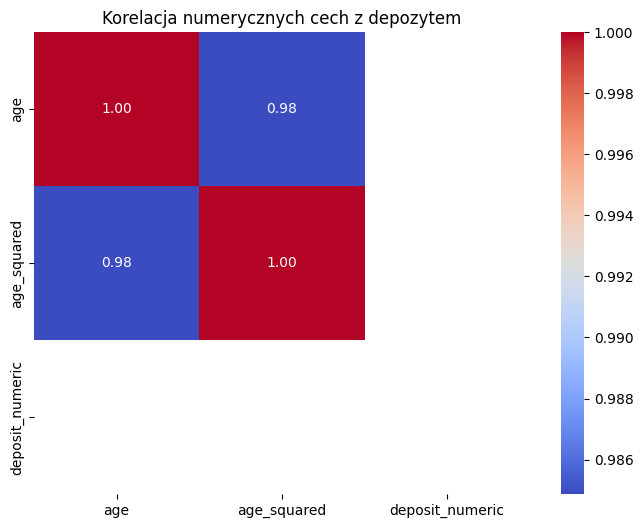

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# numeric features + target
numeric_cols = ['age', 'age_squared','deposit_numeric']

corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelacja numerycznych cech z depozytem')
plt.show()

### Wnioski

1️⃣ Główne cechy (high importance) – silna korelacja z `deposit`

| Cecha                             | Typ / rola                    | Uzasadnienie                                                                                                                            |
| --------------------------------- | ----------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| `log_balance` / `balance_shifted` | Confounder                    | Silna korelacja z depozytem. Saldo wpływa na decyzję otwarcia depozytu i może wpływać na szansę bycia wybranym do kontaktu (treatment). |
| `age` / `age_squared`             | Confounder                    | Starsi klienci mają wyższe P(deposit). Można uwzględnić w propensity score lub jako kontrola w modelu.                                  |
| `was_contacted_before`            | Confounder / proxy propensity | Historia kontaktów wpływa na otwarcie depozytu i może korelować z treatment (czy klient dostał ofertę).                                 |
| `has_debt`                        | Confounder                    | Długi i zobowiązania finansowe wpływają na decyzję o depozycie i mogą być związane z treatment.                                         |
| `treatment`                       | Treatment                     | Główna zmienna wyjaśniająca – kontakt telefoniczny / kampania marketingowa.                                                             |
| `financial_stress`                | Confounder                    | Łączy saldo negatywne, pożyczki i default – wpływa na decyzję depozytu i treatment.                                                     |

**Wskazówka:** te zmienne **powinny iść do modelu** jako zmienne kontrolne lub do propensity score.

---

2️⃣ Średnie cechy (medium importance) – umiarkowana korelacja lub znaczenie

| Cecha                                 | Typ / rola                    | Uzasadnienie                                                                                         |
| ------------------------------------- | ----------------------------- | ---------------------------------------------------------------------------------------------------- |
| `pdays`                               | Post-treatment / collider     | Liczba dni od ostatniego kontaktu – użycie w modelu może wprowadzić bias, jeśli zależy od treatment. |
| `previous` / `contact_intensity_past` | Confounder / proxy propensity | Historia wcześniejszych kontaktów – umiarkowana korelacja z deposit i treatment.                     |
| `net_balance_indicator`               | Confounder                    | Informacja o dodatnim/ujemnym saldzie. Koreluje z log_balance, może wspomagać model.                 |
| `day` / `month_num`                   | Confounder sezonowy           | Data kontaktu – umiarkowany efekt sezonowości. Można uwzględnić jako kontrola w modelu.              |

---

3️⃣ Cechy do odrzucenia / ignorowania (low importance / risky)

| Cecha                               | Typ / rola                        | Uzasadnienie                                                                                                              |
| ----------------------------------- | --------------------------------- | ------------------------------------------------------------------------------------------------------------------------- |
| `duration` (już usunięta)           | Post-treatment                    | Czas rozmowy zależy od treatment i nie powinien być używany w modelu predykcyjnym do P(deposit).                          |
| `job`                               | Niska korelacja / wiele kategorii | Można zakodować w dummies, ale korelacja z targetem słaba → małe znaczenie w modelu causal.                               |
| `contact` (categorical, po dummies) | Post-treatment                    | Typ kontaktu (`unknown`, `cellular`) – jeśli traktujemy `treatment` jako `cellular`, może być kolidującym post-treatment. |
| `month_*` dummy variables           | Sezonowość – niska korelacja      | Niektóre miesiące mają korelację, ale efekt umiarkowany. Można opcjonalnie użyć jako kontrola sezonowa.                   |
| `education_*`, `marital_*`          | Niska korelacja z deposit         | Opcjonalnie jako zmienne kontrolne, ale słaba korelacja z targetem.                                                       |

---

🔑 Podsumowanie ról:

* **Confounder** → należy uwzględnić w modelu / propensity score: `log_balance`, `age`, `financial_stress`, `has_debt`, `was_contacted_before`, `previous/contact_intensity_past`.
* **Post-treatment / collider** → **nie używać w modelu przyczynowym**: `duration`, `pdays`, czasami `contact`.
* **Opcjonalne kontrolki** → średnia lub niska korelacja: `month_num`, `day`, `education_*`, `marital_*`, `job`.

### Zapis gotowego zbioru

In [23]:
import pandas as pd

# kolumny do zapisania (główne cechy + treatment + średnie cechy opcjonalnie)
columns_to_keep = [
    'log_balance',            # confounder
    'balance_shifted',        # confounder (alternatywnie lub dodatkowo)
    'age',                    # confounder
    'age_squared',            # confounder (opcjonalnie)
    'was_contacted_before',   # confounder / proxy propensity
    'has_debt',               # confounder
    'financial_stress',       # confounder
    'treatment',              # treatment
    'previous',               # medium importance / proxy propensity
    'net_balance_indicator',  # medium importance / confounder
    'day',                    # medium importance / sezonowość
    'month_num',              # średnia kontrola sezonowa
    'month_mar',
    'month_oct',
    'month_sep',
    'month_dec',
    'marital_single',
    'education_tertiary',
    'marital_married',
    'pdays',
    'deposit',
    'deposit_numeric',
    # 'pdays'                  # post-treatment – raczej pomijamy w modelu przyczynowym
]

df_selected = df[columns_to_keep].copy()

df_selected.to_csv("./data/processed/bank_selected.csv", index=False)

In [24]:
df_selected = df[columns_to_keep].copy()

df_selected.glimpse()

<class 'pandas.DataFrame'>: 11162 rows of 22 columns
log_balance:            float64           [9.12598002335811, 8.838261682 ...
balance_shifted:        int64             [9191, 6893, 8118, 9324, 7032, ...
age:                    int64             [59, 56, 41, 55, 54, 42, 56, 6 ...
age_squared:            int64             [3481, 3136, 1681, 3025, 2916, ...
was_contacted_before:   int64             [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
has_debt:               int64             [1, 0, 1, 1, 0, 1, 1, 1, 1, 1, ...
financial_stress:       int64             [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...
treatment:              int64             [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
previous:               int64             [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
net_balance_indicator:  int64             [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...
day:                    int64             [5, 5, 5, 5, 5, 5, 6, 6, 6, 6, ...
month_num:              int64             [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...
month_mar:             